# Estimation for Joint Recovery of $p$ and $\theta$

We aim to jointly estimate the initial-condition parameters $p$ and the dynamic parameters $\theta = (\phi, \gamma)$ using only the final observation $h(T,x)$. The forward model is governed by the PDE

$$
\frac{\partial h(t,x)}{\partial t}
= C_0\, g(\phi; t)\, \frac{\partial}{\partial x}\big( u(\gamma; t, x)\, h(t,x)\big),
$$

with the initial condition represented by a Gaussian mixture

$$
h(0,x) = f(p).
$$

The inverse problem is formulated as the minimization of the regularized objective functional

$$
J(p,\theta)
=
\frac{1}{2}\,\|\,y - \mathcal{F}(p,\theta)\,\|_{W}^2
\;+\;
\lambda_p\, R_p(p)
\;+\;
\lambda_{\theta}\, R_{\theta}(\theta),
$$

where $y$ is the observed final state, $\mathcal{F}(p,\theta)$ is the forward PDE solution at $t=T$, and $R_p$, $R_\theta$ are regularization terms.

### Iniciar Ray 
```bash
ray start --head --dashboard-host=0.0.0.0 --node-ip-address=0.0.0.0
```



In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from starforge.blackholes.parameters_recover.parameters_recovery import ParametersRecoveryRemote
from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)
from starforge.blackholes.accretionrate.blackholesaccretionrate import ParameterAccretionRate
from starforge.blackholes.parameters_recover.utils import add_noise_to_data, gaussian_sum_from_p
from starforge.blackholes.parameters_recover.utils import make_bounds_for_gaussians
from starforge.blackholes.parameters_recover.schemes import GridParameters
import ray

In [3]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-05-21 09:01:46,769	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [4]:
mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps*100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

In [5]:
from scipy.optimize import minimize, differential_evolution


# Dados
log_MBH = np.array([
    8.000, 8.100, 8.200, 8.300, 8.400, 8.500, 8.600, 8.700,
    8.800, 8.900, 9.000, 9.100, 9.200, 9.300, 9.400, 9.500,
    9.600, 9.700, 9.800, 9.900, 10.000, 10.100, 10.200, 10.300,
    10.400, 10.500, 10.600, 10.700, 10.800, 10.900, 11.000
])

log_phi_median = np.array([
    -5.00, -5.03, -5.06, -5.09, -5.14, -5.22, -5.32, -5.47,
    -5.65, -5.87, -6.12, -6.40, -6.70, -7.02, -7.32, -7.61,
    -7.89, -8.17, -8.48, -8.79, -9.10, -9.44, -9.79, -10.10,
    -10.40, -10.80, -11.20, -11.50, -11.90, -12.30, -12.70
])



def objective_function(params):
    
    initial_condition = gaussian_sum_from_p(
            params,
        log_MBH,
            n_gauss=3
        )
    if np.any(initial_condition > 1e-3):
        return np.inf
    return np.sum((10**log_phi_median - initial_condition)**2)


result = differential_evolution(
    objective_function,
    bounds=make_bounds_for_gaussians(3,preferred_center=6),
    maxiter=1000,
    popsize=100,
    tol=0.01,
    mutation=(0.5, 1),
    strategy="best1bin",
    disp=True,

    )

differential_evolution step 1: f(x)= 1.5438202482010478e-09
differential_evolution step 2: f(x)= 4.5981147840646955e-10
differential_evolution step 3: f(x)= 4.5981147840646955e-10
differential_evolution step 4: f(x)= 4.396472532475294e-10
differential_evolution step 5: f(x)= 2.0472167233065607e-10
differential_evolution step 6: f(x)= 2.0472167233065607e-10
differential_evolution step 7: f(x)= 2.0472167233065607e-10
differential_evolution step 8: f(x)= 2.0472167233065607e-10
differential_evolution step 9: f(x)= 2.0472167233065607e-10
differential_evolution step 10: f(x)= 2.0472167233065607e-10
differential_evolution step 11: f(x)= 2.0472167233065607e-10
differential_evolution step 12: f(x)= 2.0472167233065607e-10
differential_evolution step 13: f(x)= 2.0472167233065607e-10
differential_evolution step 14: f(x)= 2.0472167233065607e-10
differential_evolution step 15: f(x)= 2.0472167233065607e-10
differential_evolution step 16: f(x)= 2.0472167233065607e-10
differential_evolution step 17: f(

In [6]:
result.x

array([4.73125533e-01, 7.00114027e-06, 8.15686444e+00, 3.02151578e+00,
       8.27115670e+00, 6.60958551e+00, 1.03897832e+00, 3.44771100e-01,
       1.71261226e-01])

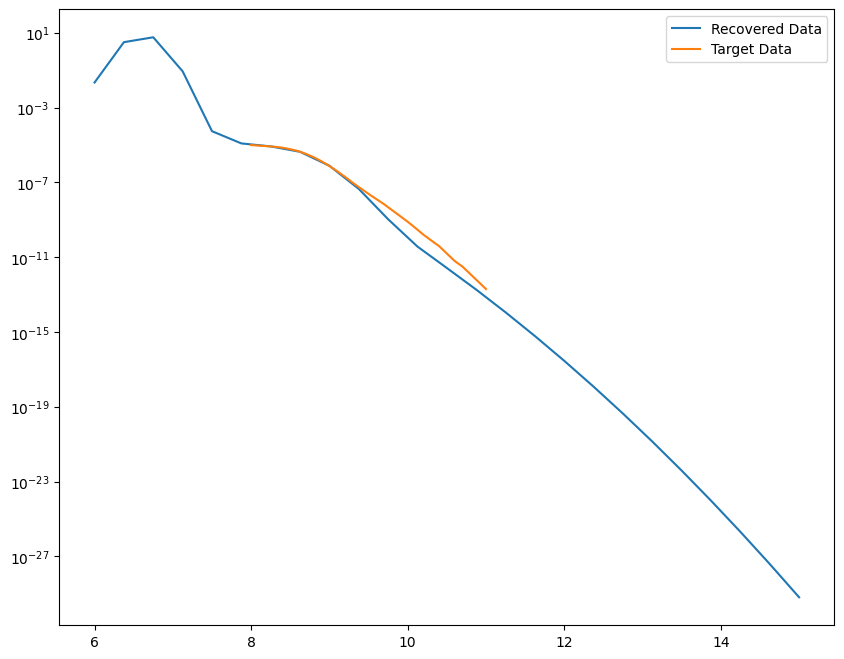

In [7]:
initial_condition_recovered = gaussian_sum_from_p(
    result.x,
    ln_mbh_grid,
    n_gauss=3
)

plt.figure(figsize=(10, 8))
plt.plot(ln_mbh_grid, initial_condition_recovered, label="Recovered Data")
plt.plot(log_MBH, 10 ** log_phi_median, label="Target Data")

plt.yscale("log")
plt.legend()
plt.show()

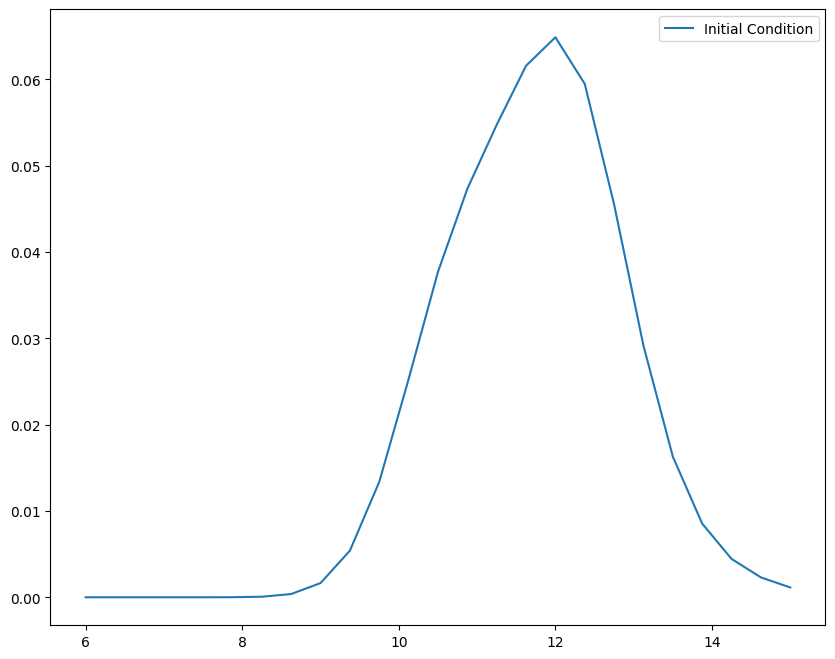

In [8]:
parameters_observational = np.array([
        3.3e-02,
        8.2e-03,
        5.4e-02,
        1.07e+01,
        1.29e+01,
        1.21e+01,
        6.93e-01,
        1.05e+00,
        7.47e-01
    ])


initial_condition = gaussian_sum_from_p(
        parameters_observational,
        ln_mbh_grid,
        n_gauss=3
    )

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, initial_condition, label="Initial Condition")
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()

In [9]:
origianl_parameters = [
            3.3e-02,
        8.2e-03,
        5.4e-02,
        1.07e+01,
        1.29e+01,
        1.21e+01,
        6.93e-01,
        1.05e+00,
        7.47e-01,
        2,
        3e-1,
        5,
        0.1,
        1,
        0.1,
        0.1,

]


print(f"Parameters:\n\n [\n{"".join(map(lambda x: f"\t{x},\n", origianl_parameters))}]")

Parameters:

 [
	0.033,
	0.0082,
	0.054,
	10.7,
	12.9,
	12.1,
	0.693,
	1.05,
	0.747,
	2,
	0.3,
	5,
	0.1,
	1,
	0.1,
	0.1,
]


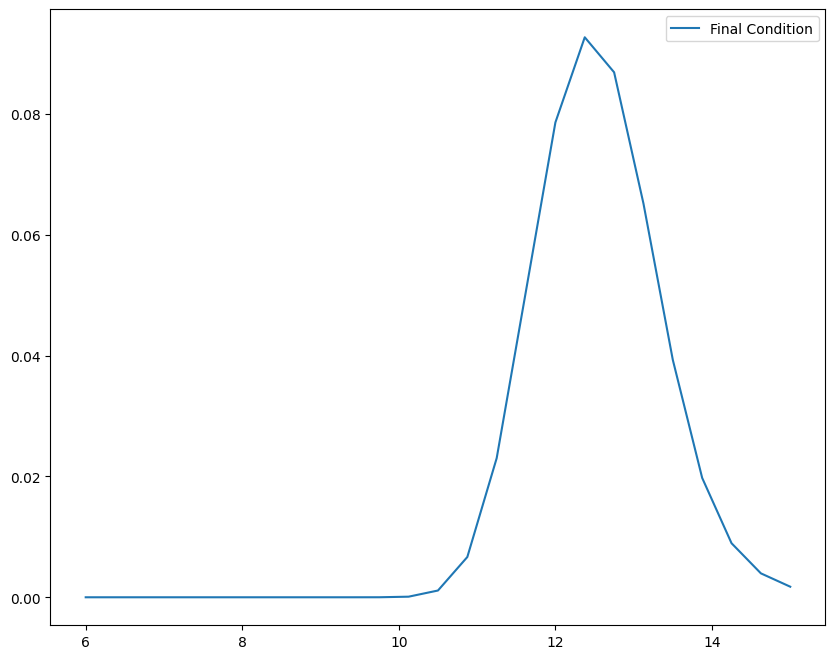

In [10]:
objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params)

accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)


# ---- Generate target data ----

outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)

noise_level = 0.1
  # 10% noise

target_data = add_noise_to_data(
    data=outputs.n_final,
    mu=0.0,
    sigma=noise_level,
    rho=0.5,
    alpha=0.5,
    seed=52,
    noise_type='mixed'
)

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, outputs.n_final, label="Final Condition")
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()


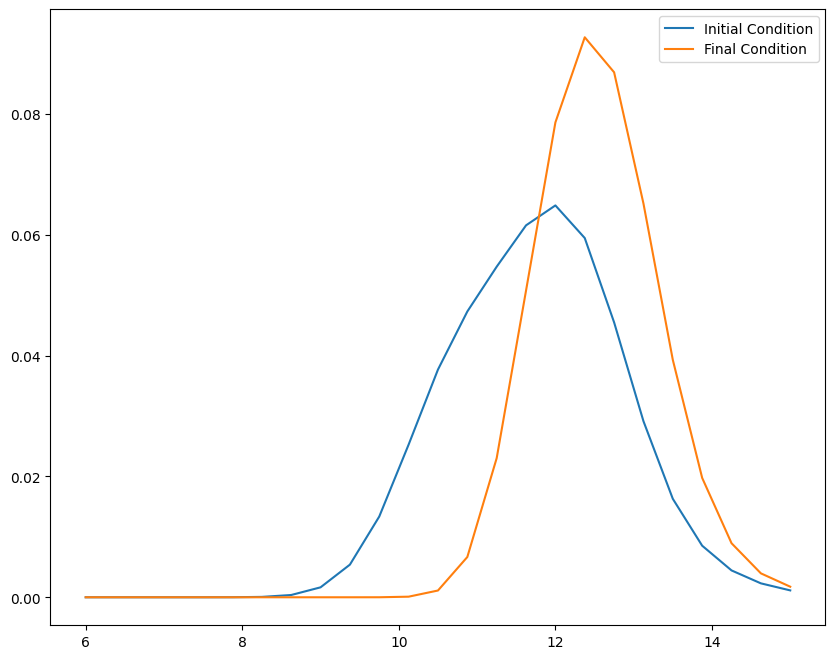

In [11]:
plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, initial_condition, label="Initial Condition")
plt.plot(ln_mbh_grid, outputs.n_final, label="Final Condition")
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()

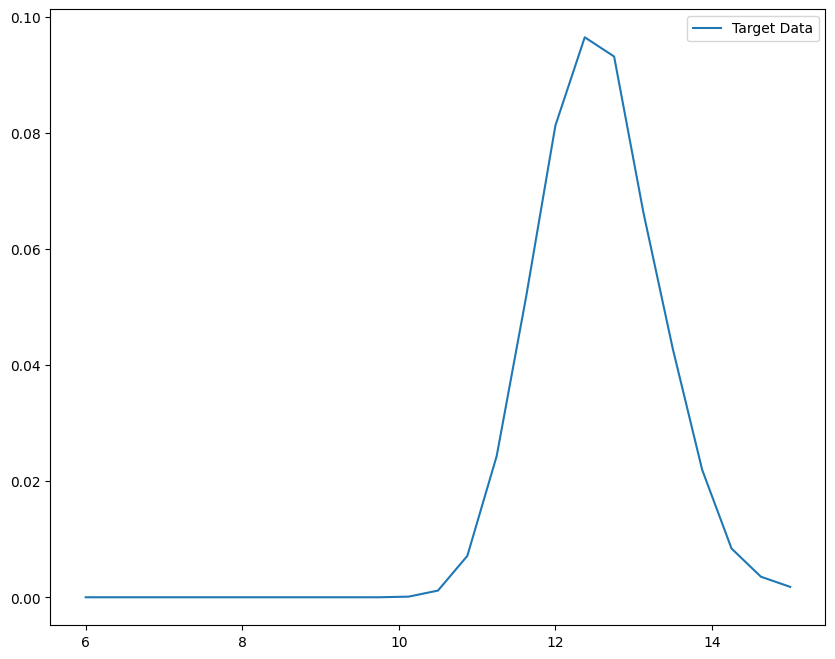

In [12]:
plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, target_data, label="Target Data")
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()

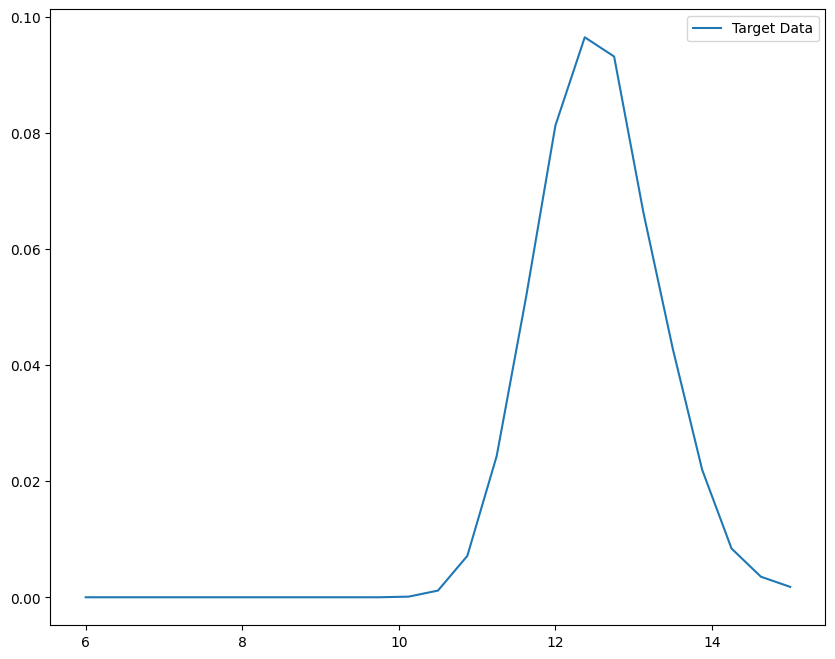

In [13]:
plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, target_data, label="Target Data")
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()

In [14]:
initial_parameters = np.abs(np.random.randn(16))

# bounds = tuple([(0.001, 15) for _ in range(16)])  # 9 for gaussians, 7 for physical params

# ---- Define bounds for optimization ----

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)


bounds.extend([  # For eta, tau_par, alpha_par
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),   # tau_par Gyr
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),    # t_q Gyr
    (0.01, 0.5),   # b_1
    (0.01, 0.5)    # b_2
])

result = ray.get(
    objective_function.optimizer.remote(
        bounds=bounds,
        target_data=target_data,
        fast_mode=False,
        use_de=True
    )
)

print("Optimized Parameters:", result)

(ParametersRecovery pid=482340) Starting optimization ...
(ParametersRecovery pid=482340) Objective value: 1.426972e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 1.371856e+02 | Context: Minimum detected in annealing process


(ParametersRecovery pid=482340) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=482340)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=482340) Objective value: 1.176847e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 1.174843e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 1.168145e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 1.166581e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 1.145390e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 1.141440e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 1.140627e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 1.137663e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 1.135829e+02 | Context: Minimum detected in annealing process
(

(ParametersRecovery pid=482340) /home/eduardo/Projects/starforge2/src/starforge/blackholes/parameters_recover/parameters_recovery.py:230: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=482340)   normalization_model = np.log10(params_array[-n:] + epsilon)


(ParametersRecovery pid=482340) Objective value: 9.181680e+00 | Context: Detection occurred in local search
(ParametersRecovery pid=482340) Objective value: 9.168108e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 9.148352e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 9.143446e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 9.134019e+00 | Context: Detection occurred in local search
(ParametersRecovery pid=482340) Objective value: 9.134002e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 9.133911e+00 | Context: Detection occurred in local search
(ParametersRecovery pid=482340) Objective value: 9.131611e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=482340) Objective value: 9.131364e+00 | Context: Minimum detected in annealing process
(Parameter

In [15]:
expected = [2, 5, 0.3, 0.1, 1.0, 0.1, 0.1]
print(
    f"Recovery: [{', '.join(map(str, result.x[-7:]))}]"
    "\n"
    f"Expected: [{', '.join(map(str, expected))}]"
)

Recovery: [1.7604460557590047, 4.080266014522453, 0.24365599180111094, 0.011050861803277261, 0.5148014460637952, 0.4003626806417576, 0.4006698002861691]
Expected: [2, 5, 0.3, 0.1, 1.0, 0.1, 0.1]


In [ ]:
result.x
print(f"Parameters:\n\n [\n{"".join(map(lambda x: f"\t{x},\n", result.x))}]")

Parameters:

 [
	0.05273359327407367,
	0.011467847057171736,
	0.026097510156319496,
	12.072707599760488,
	10.298889797392917,
	12.248644055983148,
	0.8782954413395555,
	0.3361290094001619,
	0.9321374394972047,
	1.7604460557590047,
	4.080266014522453,
	0.24365599180111094,
	0.011050861803277261,
	0.5148014460637952,
	0.4003626806417576,
	0.4006698002861691,
]


(ParametersRecovery pid=482340) Optimization completed | Final Objective: 9.104939e+00


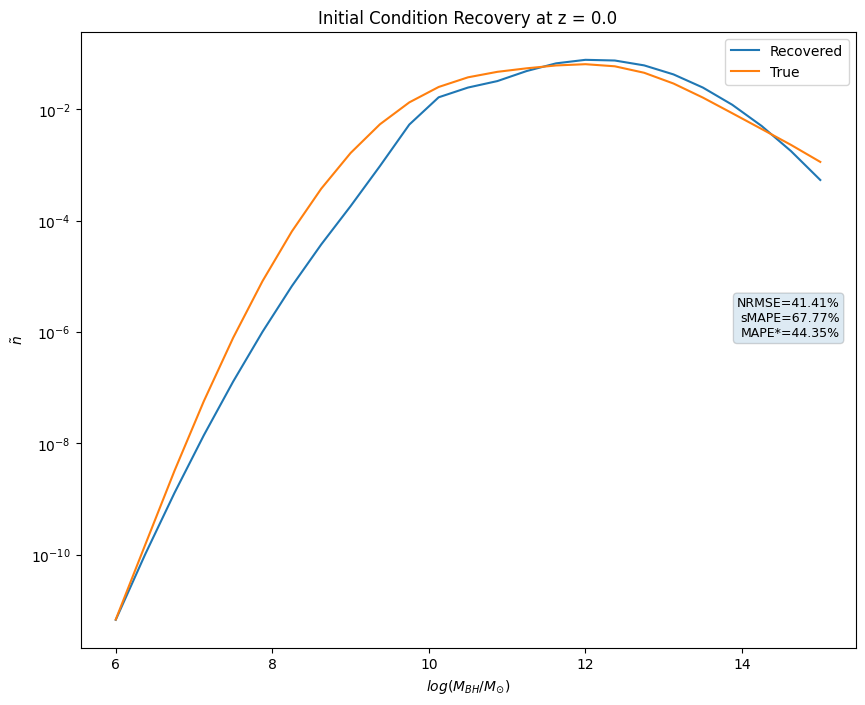

In [17]:
best_params = result.x
best_fun = result.fun


MODEL_PARAM_COUNT = 7
gaussian_parameters = best_params[:-MODEL_PARAM_COUNT]
model_parameters = best_params[-MODEL_PARAM_COUNT:]
parameters_observational = np.array([
        3.3e-02,
        8.2e-03,
        5.4e-02,
        1.07e+01,
        1.29e+01,
        1.21e+01,
        6.93e-01,
        1.05e+00,
        7.47e-01
    ])


grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps*1000
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

initial_condition_recovered = gaussian_sum_from_p(
        gaussian_parameters,
        ln_mbh_grid,
        n_gauss=3
    )

# métricas robustas
nrmse = nrmse_percent(initial_condition, initial_condition_recovered, denom='mean')
s_mape = smape_percent(initial_condition, initial_condition_recovered, eps=1e-12)
stab_mape = stabilized_mape_percent(initial_condition, initial_condition_recovered, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, initial_condition_recovered, label="Recovered")
plt.plot(ln_mbh_grid, initial_condition, label="True")
plt.xlabel(r'$log(M_{BH} / M_{\odot})$')
plt.ylabel(r'$\tilde{n}$')
plt.title(f"Initial Condition Recovery at z = {grid_params.z_f}")
plt.text(0.98, 0.50, metrics_text, transform=plt.gca().transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
plt.yscale("log")
plt.legend()
plt.show()
plt.close()

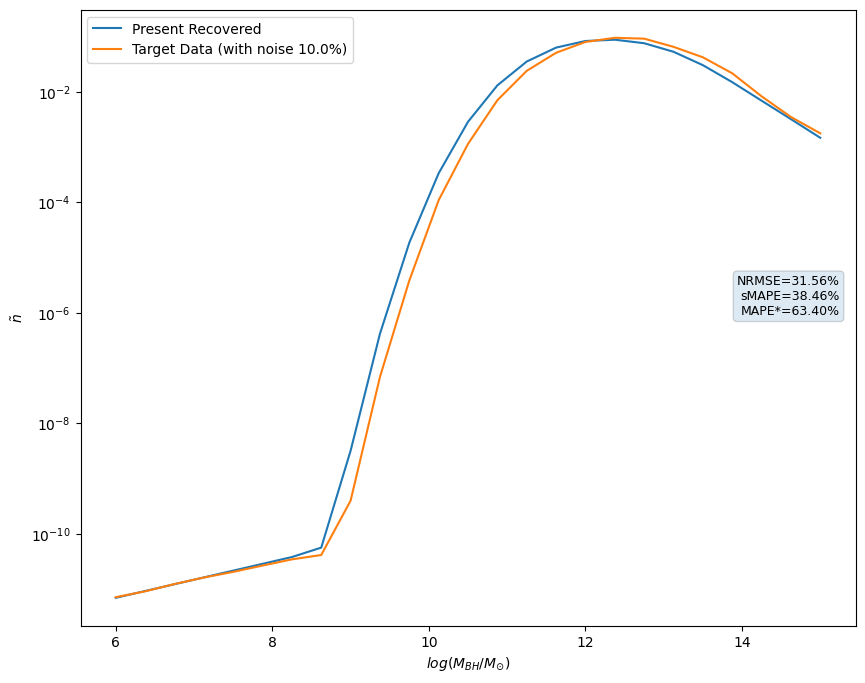

In [18]:
objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params)

# Build physical model parameters
accretion_params = ParameterAccretionRate(
    # Bloco 2 -- Parametros da Luminosidade
    mbh_par=model_parameters[-MODEL_PARAM_COUNT] * 1e11,
    tau_par=model_parameters[-MODEL_PARAM_COUNT+1] * 1e9,
    alpha_par=model_parameters[-MODEL_PARAM_COUNT+2],

    # Bloco 3 -- Parametros da eficiencia Radiativa
    eta=model_parameters[-MODEL_PARAM_COUNT+3],
    t_q=model_parameters[-MODEL_PARAM_COUNT+4] * 1e9,
    b_1=model_parameters[-MODEL_PARAM_COUNT+5],
    b_2=model_parameters[-MODEL_PARAM_COUNT+6]
)

# ---- Generate target data ----

outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)


# métricas robustas
nrmse = nrmse_percent(target_data, outputs.n_final, denom='mean')
s_mape = smape_percent(target_data, outputs.n_final, eps=1e-12)
stab_mape = stabilized_mape_percent(target_data, outputs.n_final, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, outputs.n_final, label="Present Recovered")
plt.plot(ln_mbh_grid,target_data, label=f"Target Data (with noise {noise_level*100:.1f}%)")
plt.xlabel(r'$log(M_{BH} / M_{\odot})$')
plt.ylabel(r'$\tilde{n}$')
plt.yscale("log")
plt.text(0.98, 0.50, metrics_text, transform=plt.gca().transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
plt.legend()
plt.show()
plt.close()

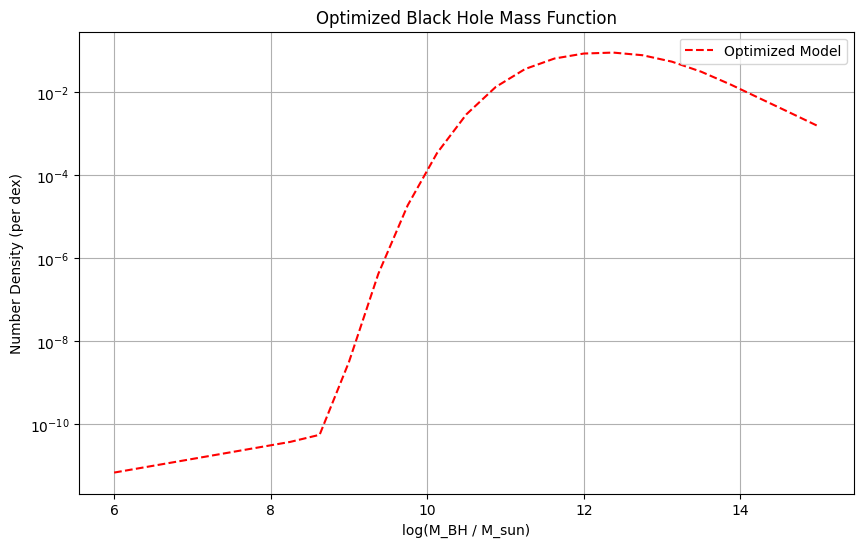

In [19]:
# === FIGURA 1 ===
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(
    outputs.ln_mbh_grid,
    outputs.n_final,
    label='Optimized Model',
    color='red',
    linestyle='--'
)
ax1.set_yscale('log')
ax1.set_xlabel('log(M_BH / M_sun)')
ax1.set_ylabel('Number Density (per dex)')
ax1.set_title('Optimized Black Hole Mass Function')
ax1.legend()
ax1.grid(True)



Metrics for Initial Condition Comparison:
NRMSE=41.41%
sMAPE=67.77%
MAPE*=44.35%
Metrics for Present Data Comparison:
NRMSE=31.56%
sMAPE=38.46%
MAPE*=63.40%


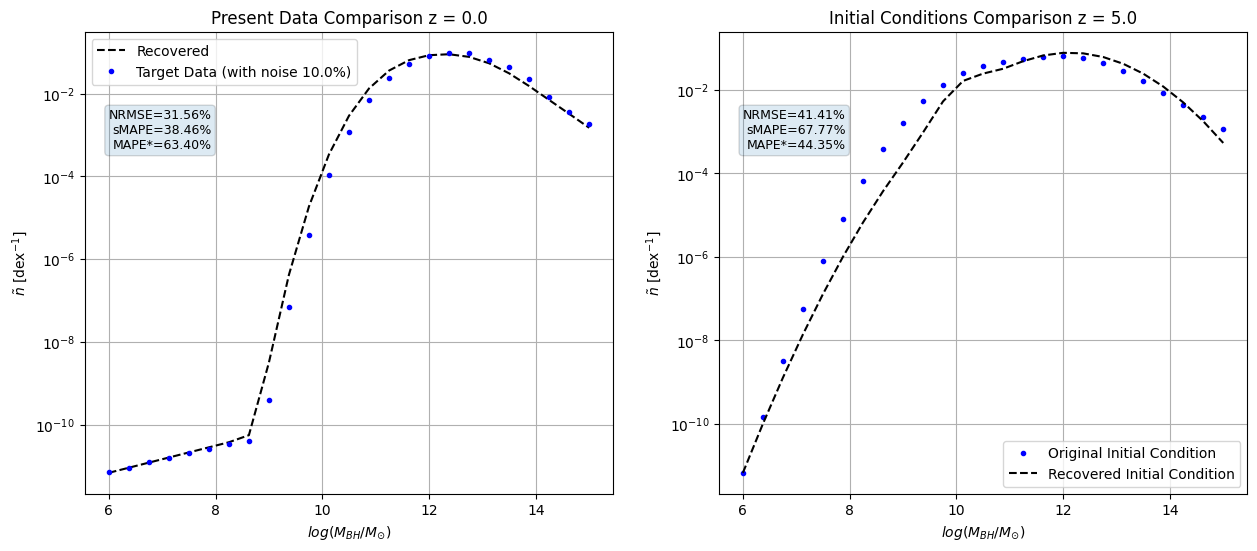

In [20]:

# === FIGURA 2 ===
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
ax2.plot(
    outputs.ln_mbh_grid,
    initial_condition,
    '.',
    label='Original Initial Condition',
    color='blue'
)
ax2.plot(
    outputs.ln_mbh_grid,
    initial_condition_recovered,
    '--',
    label='Recovered Initial Condition',
    color='black',
)

# métricas robustas
nrmse = nrmse_percent(initial_condition, initial_condition_recovered, denom='mean')
s_mape = smape_percent(initial_condition, initial_condition_recovered, eps=1e-12)
stab_mape = stabilized_mape_percent(initial_condition, initial_condition_recovered, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

print("Metrics for Initial Condition Comparison:")
print(metrics_text)

ax2.set_yscale('log')
ax2.set_xlabel(r'$log(M_{BH} / M_{\odot})$')
ax2.set_ylabel(r'$\tilde{n}$ [dex$^{-1}$]')

ax2.text(0.24, 0.74, metrics_text, transform=ax2.transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
ax2.set_title(f'Initial Conditions Comparison z = {grid_params.z_i}')
ax2.legend()
ax2.grid(True)


# métricas robustas
nrmse = nrmse_percent(target_data, outputs.n_final, denom='mean')
s_mape = smape_percent(target_data, outputs.n_final, eps=1e-12)
stab_mape = stabilized_mape_percent(target_data, outputs.n_final, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

print("Metrics for Present Data Comparison:")
print(metrics_text)

ax1.plot(
    outputs.ln_mbh_grid,
    outputs.n_final,
    '--',
    label="Recovered",
    color='black'
)

ax1.plot(
    outputs.ln_mbh_grid,
    target_data,
    '.',
    label=f"Target Data (with noise {noise_level*100:.1f}%)",
    color='blue',
)

ax1.set_xlabel(r'$log(M_{BH} / M_{\odot})$')
ax1.set_ylabel(r'$\tilde{n}$ [dex$^{-1}$]')
ax1.set_yscale('log')
ax1.text(0.24, 0.74, metrics_text, transform=ax1.transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
ax1.set_title(f'Present Data Comparison z = {grid_params.z_f}')
ax1.legend()
ax1.grid(True)

plt.show()

In [21]:
def generate_target_data(noise_level=0.1):
    parameters_observational = np.array([
            3.3e-02,
            8.2e-03,
            5.4e-02,
            1.07e+01,
            1.29e+01,
            1.21e+01,
            6.93e-01,
            1.05e+00,
            7.47e-01
        ])

    mbh_steps = 25

    grid_params = GridParameters(
        mbh_steps=mbh_steps,
        z_steps=mbh_steps*100
    )

    ln_mbh_grid = np.linspace(
        grid_params.mbh_i,
        grid_params.mbh_f,
        grid_params.mbh_steps
    )

    initial_condition = gaussian_sum_from_p(
            parameters_observational,
            ln_mbh_grid,
            n_gauss=3
        )
    objective_function = ParametersRecoveryRemote.remote(
        grid_params=grid_params)

    accretion_params = ParameterAccretionRate(
        mbh_par=2e11,
        alpha_par=3e-1,
        tau_par=5e9,
        eta=0.1,
        t_q=1e9,
        b_1=0.1,
        b_2=0.1,
    )


    # ---- Generate target data ----

    outputs = ray.get(
        objective_function.directly_problem.remote(
            initial_condition,
            accretion_params
        )
    )

    target_data = add_noise_to_data(
        data=outputs.n_final,
        mu=0.0,
        sigma=noise_level,
        rho=0.5,
        alpha=0.5,
        seed=52,
        noise_type='mixed'
    )
    return target_data, initial_condition, ln_mbh_grid, grid_params


params =  {    

    "0.01": [
        5.09e-2, 3.78e-2, 1.03e-2,
        1.22e1, 1.08e1, 1.29e1,
        6.82e-1, 7.12e-1, 9.98e-1,
        4.90e0, 7.34e0, 2.99e-1,
        2.59e-1, 2.34e0,
        3.47e-1, 3.22e-2
    ],

    "0.03": [
        8.21e-3, 3.81e-2, 5.40e-2,
        1.29e1, 1.08e1, 1.22e1,
        1.05e0, 6.95e-1, 7.02e-1,
        2.43e0, 5.42e0, 3.02e-1,
        1.94e-2, 4.29e0,
        3.57e-1, 2.17e-1
    ],

    "0.05": [
        3.44e-2, 3.20e-3, 6.06e-2,
        1.07e1, 1.36e1, 1.22e1,
        7.02e-1, 9.85e-1, 7.67e-1,
        4.96e0, 7.41e0, 2.97e-1,
        1.32e-1, 4.13e0,
        3.12e-1, 2.67e-1
    ],

    "0.10": [
        2.11e-2, 4.29e-2, 3.27e-2,
        1.04e1, 1.18e1, 1.23e1,
        5.28e-1, 7.82e-1, 9.47e-1,
        4.88e0, 7.06e0, 3.07e-1,
        1.01e-1, 4.27e0,
        4.63e-1, 4.19e-1
    ]
}

objective_function = ParametersRecoveryRemote.remote(
grid_params=grid_params)

results = {}
for parameter in params.keys():

    target_data, initial_condition, ln_mbh_grid, grid_params = generate_target_data(noise_level=float(parameter))

    initial_condition_recovered =  gaussian_sum_from_p(
        params[parameter][:-MODEL_PARAM_COUNT],
        ln_mbh_grid,
        n_gauss=3
    )

    # Build physical model parameters
    accretion_params = ParameterAccretionRate(
        # Bloco 2 -- Parametros da Luminosidade
        mbh_par=params[parameter][-MODEL_PARAM_COUNT] * 1e11,
        tau_par=params[parameter][-MODEL_PARAM_COUNT+1] * 1e9,
        alpha_par=params[parameter][-MODEL_PARAM_COUNT+2],

        # Bloco 3 -- Parametros da eficiencia Radiativa
        eta=params[parameter][-MODEL_PARAM_COUNT+3],
        t_q=params[parameter][-MODEL_PARAM_COUNT+4] * 1e9,
        b_1=params[parameter][-MODEL_PARAM_COUNT+5],
        b_2=params[parameter][-MODEL_PARAM_COUNT+6]
    )

    # ---- Generate target data ----

    outputs = ray.get(
        objective_function.directly_problem.remote(
            initial_condition,
            accretion_params
        )
    )

    # métricas robustas
    nrmse = nrmse_percent(target_data, outputs.n_final, denom='mean')
    s_mape = smape_percent(target_data, outputs.n_final, eps=1e-12)
    stab_mape = stabilized_mape_percent(target_data, outputs.n_final, eps=1e-8)

    metrics_text = (
        f'NRMSE={nrmse:.2f}%\n'
        f'sMAPE={s_mape:.2f}%\n'
        f'MAPE*={stab_mape:.2f}%'
    )

    results[parameter] = {
        'metrics': metrics_text,
        'initial_condition_recovered': initial_condition_recovered,
        'initial_condition': initial_condition,
        'target_data': target_data,
        'outputs_n_final': outputs.n_final,
        'ln_mbh_grid': ln_mbh_grid,
        'grid_params': grid_params
    }


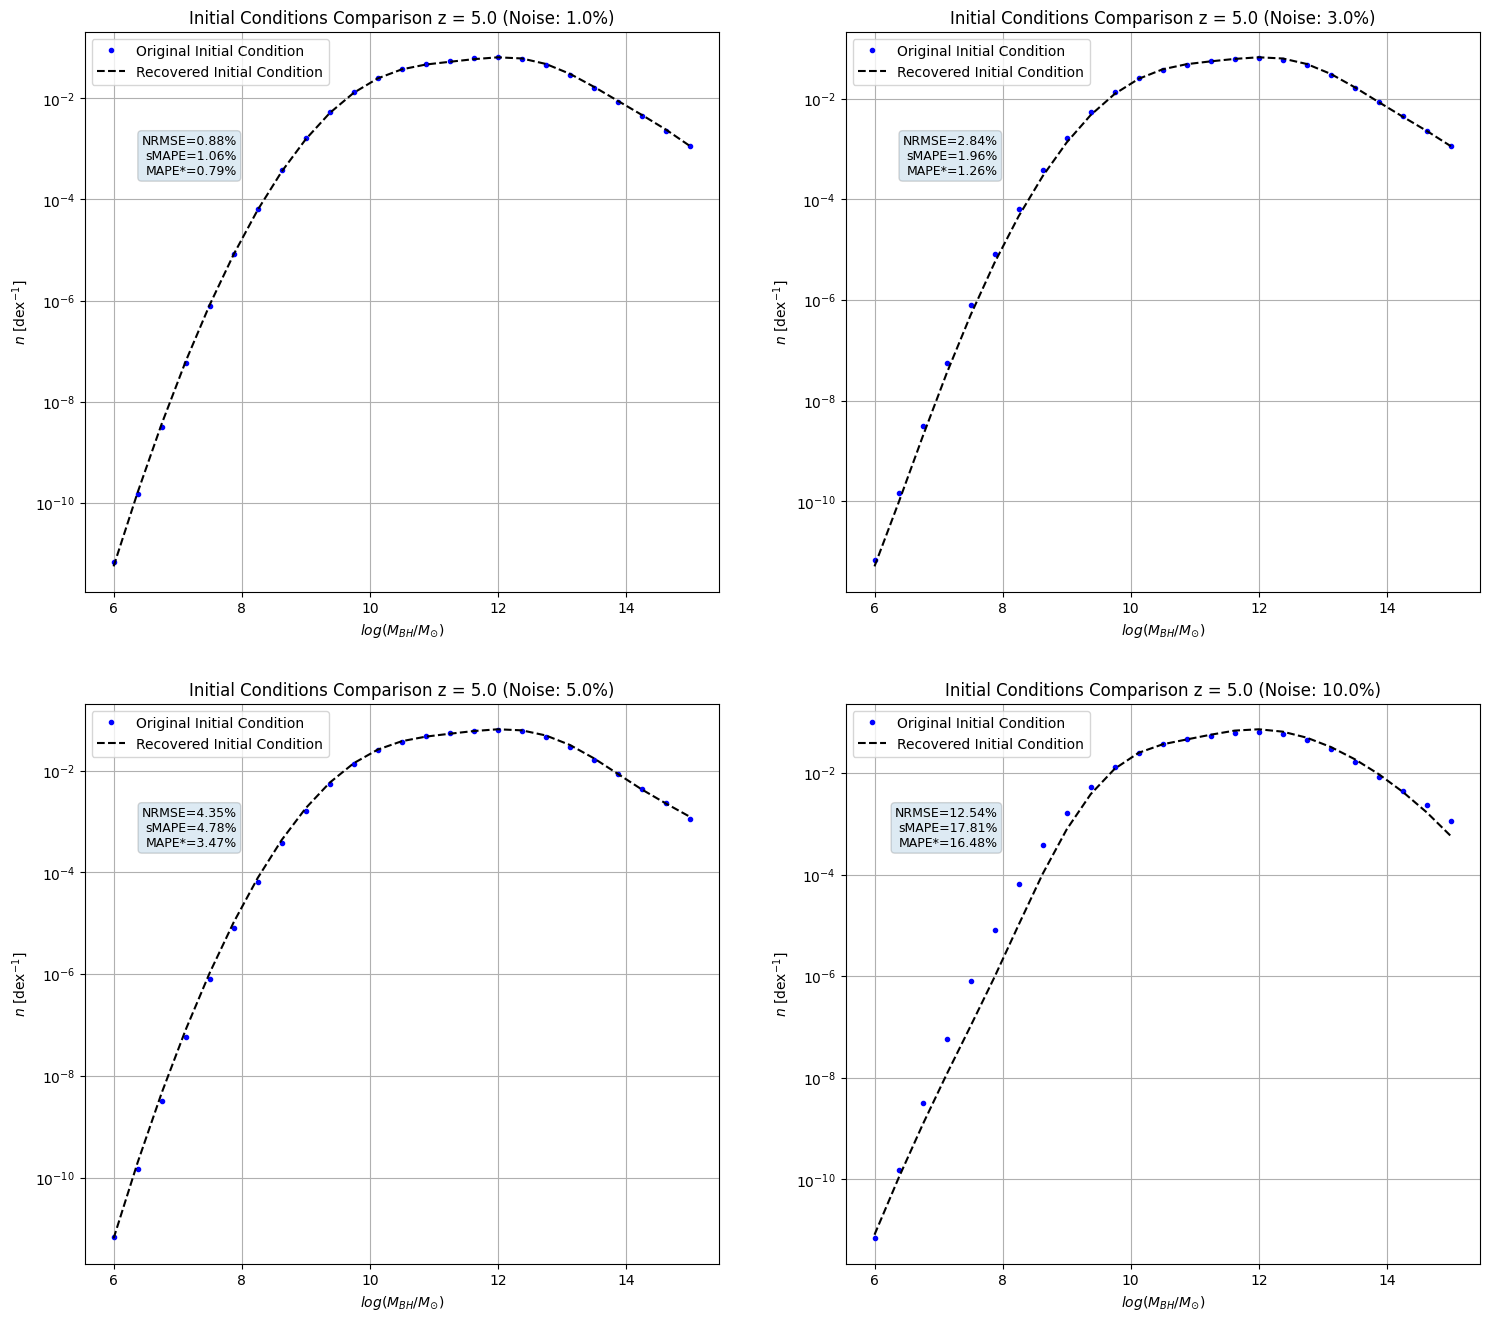

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))


axes = axes.flatten()  


for i, noise in enumerate(results.keys()):
    ax = axes[i]
    res = results[noise]

    ax.plot(
        res['ln_mbh_grid'],
        res['initial_condition'],
        '.',
        label='Original Initial Condition',
        color='blue'
    )
    ax.plot(
        res['ln_mbh_grid'],
        res['initial_condition_recovered'],
        '--',
        label='Recovered Initial Condition',
        color='black',
    )

    ax.set_yscale('log')
    ax.set_xlabel(r'$log(M_{BH} / M_{\odot})$')
    ax.set_ylabel(r'$n$ [dex$^{-1}$]')

    ax.text(0.24, 0.74, res['metrics'], transform=ax.transAxes,
                        fontsize=9, va='bottom', ha='right',
                        bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
    ax.set_title(f'Initial Conditions Comparison z = {res["grid_params"].z_i} (Noise: {float(noise)*100:.1f}%)')
    ax.legend()
    ax.grid(True)

plt.show()



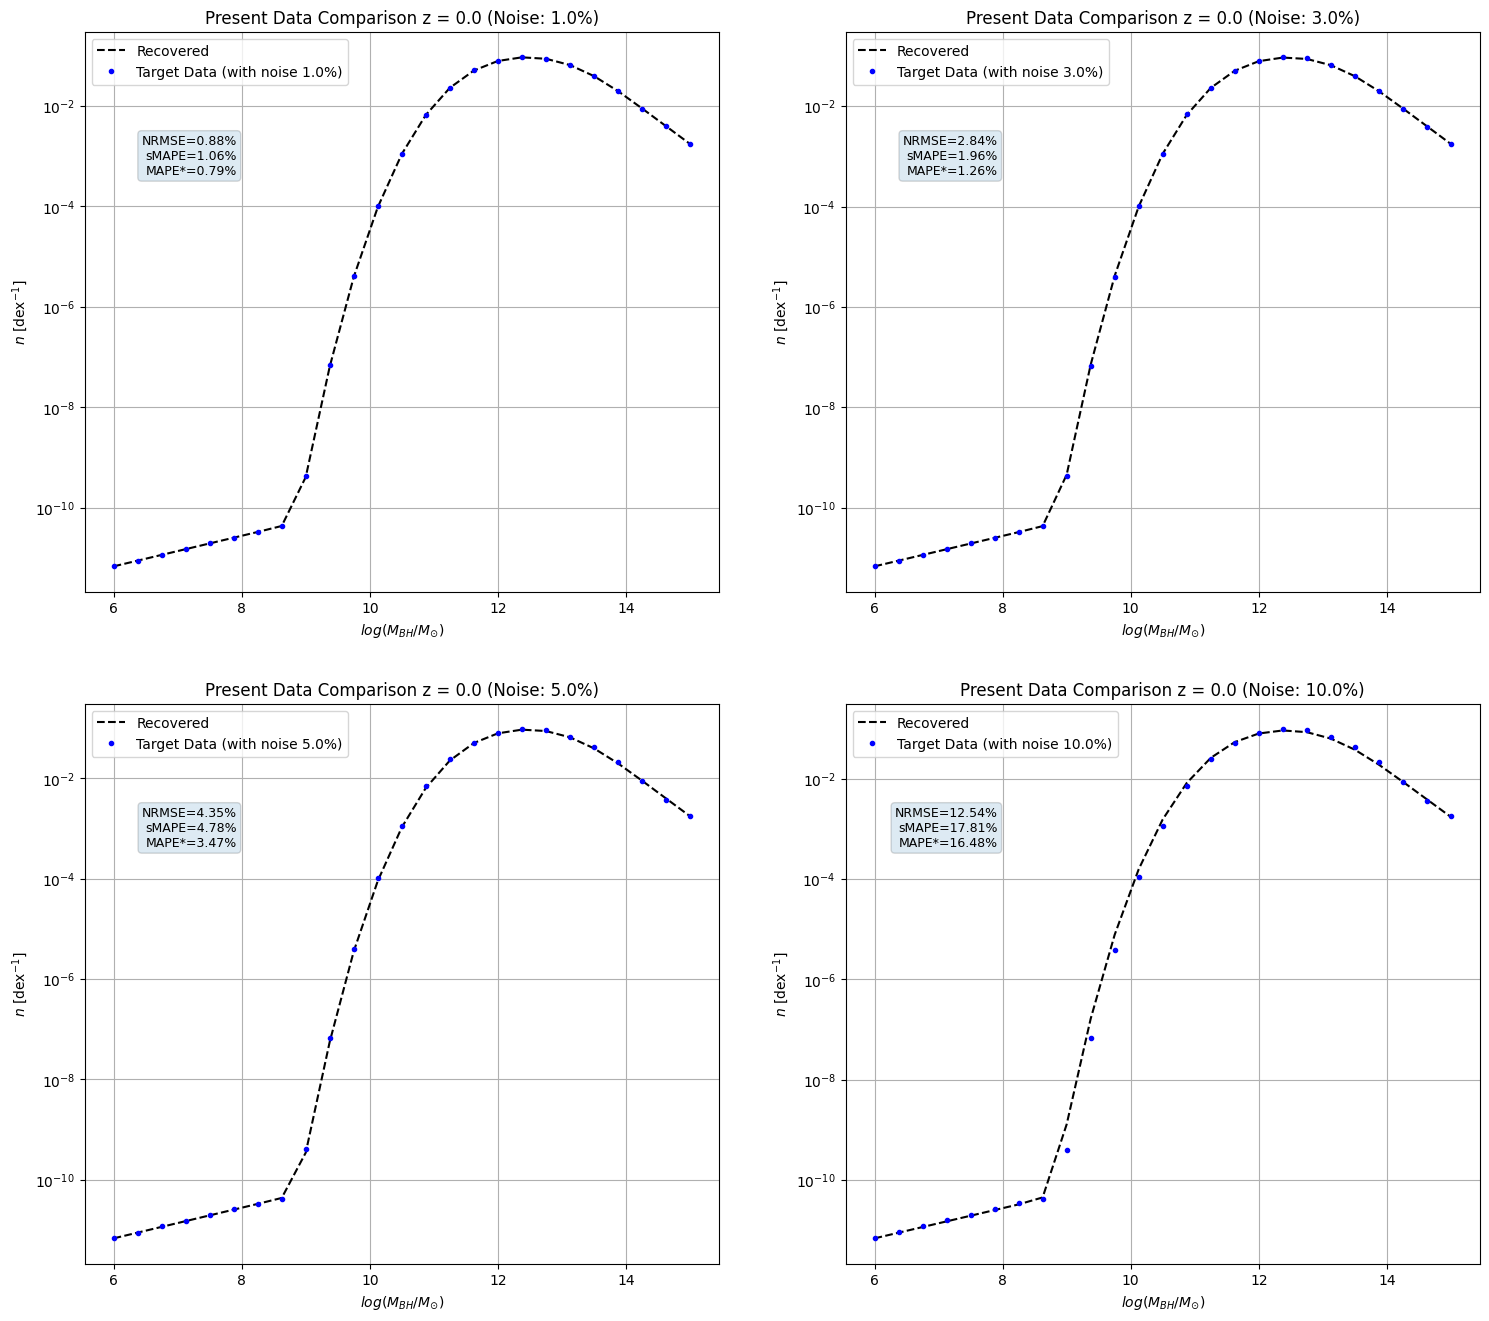

In [23]:

fig2, axes2 = plt.subplots(2, 2, figsize=(18, 16))
axes2 = axes2.flatten()
for i, noise in enumerate(results.keys()):
    ax2 = axes2[i]
    res = results[noise]

    ax2.plot(
        res['ln_mbh_grid'],
        res['outputs_n_final'],
        '--',
        label="Recovered",
        color='black'
    )

    ax2.plot(
        res['ln_mbh_grid'],
        res['target_data'],
        '.',
        label=f"Target Data (with noise {float(noise)*100:.1f}%)",
        color='blue',
    )

    ax2.set_xlabel(r'$log(M_{BH} / M_{\odot})$')
    ax2.set_ylabel(r'$n$ [dex$^{-1}$]')
    ax2.set_yscale('log')
    ax2.text(0.24, 0.74, res['metrics'], transform=ax2.transAxes,
                        fontsize=9, va='bottom', ha='right',
                        bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
    ax2.set_title(f'Present Data Comparison z = {res["grid_params"].z_f} (Noise: {float(noise)*100:.1f}%)')
    ax2.legend()
    ax2.grid(True)

plt.show()

In [ ]:
ray.shutdown()

In [24]:
# ============================================================
# MONTE CARLO DEGENERACY ANALYSIS
# ============================================================

import pandas as pd
import seaborn as sns

N_MONTE_CARLO = 1500

# ------------------------------------------------------------
# Tolerance epsilon
# ------------------------------------------------------------

epsilon = np.linalg.norm(target_data - outputs.n_final)

print(f"Tolerance epsilon = {epsilon:.5e}")

# ------------------------------------------------------------
# Benchmark parameters
# ------------------------------------------------------------

benchmark_params = np.array([
    3.3e-02,
    8.2e-03,
    5.4e-02,
    1.07e+01,
    1.29e+01,
    1.21e+01,
    6.93e-01,
    1.05e+00,
    7.47e-01
])

# ------------------------------------------------------------
# Containers
# ------------------------------------------------------------

accepted_parameters = []
all_distances = []

# ------------------------------------------------------------
# Monte Carlo exploration
# ------------------------------------------------------------

for i in range(N_MONTE_CARLO):

    # --------------------------------------------------------
    # Perturb Gaussian parameters
    # --------------------------------------------------------

    perturbed = benchmark_params.copy()

    # amplitudes
    perturbed[0:3] *= (
        1.0 + 0.05 * np.random.randn(3)
    )

    # centers
    perturbed[3:6] += (
        0.10 * np.random.randn(3)
    )

    # widths
    perturbed[6:9] *= (
        1.0 + 0.05 * np.random.randn(3)
    )

    # avoid negative sigmas
    perturbed[6:9] = np.clip(
        perturbed[6:9],
        0.05,
        None
    )

    # --------------------------------------------------------
    # Build perturbed initial condition
    # --------------------------------------------------------

    perturbed_initial = gaussian_sum_from_p(
        perturbed,
        ln_mbh_grid,
        n_gauss=3
    )

    # --------------------------------------------------------
    # Forward model
    # --------------------------------------------------------

    perturbed_outputs = ray.get(
        objective_function.directly_problem.remote(
            perturbed_initial,
            accretion_params
        )
    )

    # --------------------------------------------------------
    # Distance to reference
    # --------------------------------------------------------

    d_j = np.linalg.norm(
        perturbed_outputs.n_final - target_data
    )

    all_distances.append(d_j)

    # --------------------------------------------------------
    # Accept if degenerate
    # --------------------------------------------------------

    if d_j <= epsilon:
        accepted_parameters.append(perturbed)

# ============================================================
# RESULTS
# ============================================================

accepted_parameters = np.array(accepted_parameters)

print(f"Accepted realizations: {len(accepted_parameters)}")

# ============================================================
# HISTOGRAM
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    all_distances,
    bins=40,
    alpha=0.7
)

plt.axvline(
    epsilon,
    color='red',
    linestyle='--',
    label=r'$\epsilon$'
)

plt.xlabel(r'$d_j$')
plt.ylabel('Counts')

plt.title('Distribution of Monte Carlo Distances')

plt.legend()

plt.show()


# ============================================================
# PAIRWISE DEGENERACY MAP
# ============================================================

columns = [
    r'$A_1$',
    r'$A_2$',
    r'$A_3$',
    r'$\mu_1$',
    r'$\mu_2$',
    r'$\mu_3$',
    r'$\sigma_1$',
    r'$\sigma_2$',
    r'$\sigma_3$'
]

df = pd.DataFrame(
    accepted_parameters,
    columns=columns
)

# ------------------------------------------------------------
# Pairplot
# ------------------------------------------------------------

g = sns.pairplot(
    df,
    corner=True,
    diag_kind='hist',
    plot_kws={
        's': 12,
        'alpha': 0.5
    }
)

g.fig.suptitle(
    'Pairwise Parameter Distributions for Perturbed Initial Conditions',
    y=1.02
)

plt.show()

Tolerance epsilon = 1.25503e-02


KeyboardInterrupt: 